# Phase 3 — Base Model Training & Comparison

**Goal:** Train 6 classical ML classifiers on all 3 vectorizations, evaluate each with
Accuracy / Precision / Recall / F1, plot confusion matrices, and save a full results table.

**Models:**

| # | Model | Notes |
|---|---|---|
| 1 | `ComplementNB` | Best NB variant for text; **only** for sparse features (Count/TF-IDF) |
| 2 | `GaussianNB` | Accepts negative floats; **only** for Word2Vec dense features |
| 3 | `LinearSVC` (calibrated) | Fast linear SVM with probability support |
| 4 | `DecisionTreeClassifier` | Interpretable but weak on high-dim sparse |
| 5 | `RandomForestClassifier` | Ensemble of trees |
| 6 | `KNeighborsClassifier` | Slow on sparse but included for completeness |
| 7 | `AdaBoostClassifier` | Boosting baseline |

**Vectorizations:** CountVectorizer / TF-IDF / Word2Vec  
Total experiments: up to 7 models × 3 vectorizers = 21 runs
(NB models each serve one vectorizer type, so effectively 19 unique runs)

In [1]:
import sys, os, time, warnings
warnings.filterwarnings('ignore')

REPO_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..'))
for p in [REPO_ROOT, os.path.join(REPO_ROOT, 'src')]:
    if p not in sys.path:
        sys.path.insert(0, p)

import numpy as np
import pandas as pd
import scipy.sparse as sp
import matplotlib.pyplot as plt

from sklearn.naive_bayes       import ComplementNB, GaussianNB
from sklearn.svm               import LinearSVC
from sklearn.calibration       import CalibratedClassifierCV
from sklearn.tree              import DecisionTreeClassifier
from sklearn.ensemble          import RandomForestClassifier, AdaBoostClassifier
from sklearn.neighbors         import KNeighborsClassifier

from evaluation import evaluate_model, plot_confusion_matrix, print_metrics_table, save_results_csv, show_prediction_examples, full_report

DATA_PROC = os.path.join(REPO_ROOT, 'data', 'processed')
CM_DIR    = os.path.join(REPO_ROOT, 'outputs', 'confusion_matrices')
RES_DIR   = os.path.join(REPO_ROOT, 'outputs', 'results')
FIG_DIR   = os.path.join(REPO_ROOT, 'outputs', 'figures')
os.makedirs(CM_DIR,  exist_ok=True)
os.makedirs(RES_DIR, exist_ok=True)
os.makedirs(FIG_DIR, exist_ok=True)

print('Imports OK')

Imports OK


## 1. Load Feature Matrices

In [2]:
X_train_count = sp.load_npz(os.path.join(DATA_PROC, 'X_train_count.npz'))
X_test_count  = sp.load_npz(os.path.join(DATA_PROC, 'X_test_count.npz'))

X_train_tfidf = sp.load_npz(os.path.join(DATA_PROC, 'X_train_tfidf.npz'))
X_test_tfidf  = sp.load_npz(os.path.join(DATA_PROC, 'X_test_tfidf.npz'))

X_train_w2v   = np.load(os.path.join(DATA_PROC, 'X_train_w2v.npy'))
X_test_w2v    = np.load(os.path.join(DATA_PROC, 'X_test_w2v.npy'))

y_train = np.load(os.path.join(DATA_PROC, 'y_train.npy'))
y_test  = np.load(os.path.join(DATA_PROC, 'y_test.npy'))

# Also load raw text for prediction examples later
test_df = pd.read_csv(os.path.join(DATA_PROC, 'test.csv'), encoding='utf-8')
X_test_texts = test_df['cleaned'].fillna('').values

print('All feature matrices loaded.')
print(f'Train: {X_train_count.shape}  Test: {X_test_count.shape}')

All feature matrices loaded.
Train: (55577, 50000)  Test: (13895, 50000)


## 2. Experiment Loop

We run every model against every applicable vectorizer and collect metrics.

**NB compatibility rule:**
- `ComplementNB` requires non-negative values → CountVectorizer + TF-IDF only
- `GaussianNB` accepts any floats → Word2Vec only

In [3]:
# Vectorizer registry: name → (X_train, X_test)
vectorizers = {
    'CountVectorizer': (X_train_count, X_test_count),
    'TF-IDF':          (X_train_tfidf, X_test_tfidf),
    'Word2Vec':        (X_train_w2v,   X_test_w2v),
}

# Model registry: name → (model_instance, supported_vectorizers)
# 'all' means the model works with any vectorizer except W2V NB conflict
SPARSE_ONLY = ['CountVectorizer', 'TF-IDF']
W2V_ONLY    = ['Word2Vec']
ALL_VEC     = ['CountVectorizer', 'TF-IDF', 'Word2Vec']

models = [
    ('ComplementNB',  ComplementNB(alpha=0.1),                                     SPARSE_ONLY),
    ('GaussianNB',    GaussianNB(),                                                W2V_ONLY),
    ('SVM (Linear)',  CalibratedClassifierCV(LinearSVC(C=1.0, max_iter=2000)),     ALL_VEC),
    ('DecisionTree',  DecisionTreeClassifier(max_depth=20, random_state=42),       ALL_VEC),
    ('RandomForest',  RandomForestClassifier(n_estimators=200, n_jobs=-1,
                                             random_state=42),                     ALL_VEC),
    ('KNN',           KNeighborsClassifier(n_neighbors=7, n_jobs=-1),              ALL_VEC),
    ('AdaBoost',      AdaBoostClassifier(n_estimators=100, random_state=42),       ALL_VEC),
]

print(f'Models: {len(models)}  |  Vectorizers: {len(vectorizers)}')

Models: 7  |  Vectorizers: 3


In [4]:
results = []

for vec_name, (X_tr, X_te) in vectorizers.items():
    print(f'\n=== Vectorizer: {vec_name} ===')

    for model_name, model, supported in models:
        if vec_name not in supported:
            print(f'  [SKIP] {model_name} (not compatible with {vec_name})')
            continue

        # GaussianNB requires dense input
        X_tr_use = X_tr.toarray() if (sp.issparse(X_tr) and isinstance(model, GaussianNB)) else X_tr
        X_te_use = X_te.toarray() if (sp.issparse(X_te) and isinstance(model, GaussianNB)) else X_te

        t0 = time.time()
        model.fit(X_tr_use, y_train)
        y_pred = model.predict(X_te_use)
        elapsed = time.time() - t0

        metrics = evaluate_model(model_name, vec_name, y_test, y_pred)
        metrics['train_time_s'] = round(elapsed, 1)
        results.append(metrics)

        plot_confusion_matrix(model_name, vec_name, y_test, y_pred, CM_DIR)

        print(f'  {model_name:<18}  acc={metrics["accuracy"]:.4f}  '
              f'f1={metrics["f1"]:.4f}  ({elapsed:.1f}s)')

print('\nAll experiments done.')


=== Vectorizer: CountVectorizer ===


  ComplementNB        acc=0.8363  f1=0.8358  (0.0s)
  [SKIP] GaussianNB (not compatible with CountVectorizer)


  SVM (Linear)        acc=0.8154  f1=0.8153  (3.5s)


  DecisionTree        acc=0.7968  f1=0.7952  (2.8s)


  RandomForest        acc=0.8386  f1=0.8384  (58.5s)


...

  DecisionTree        acc=0.7415  f1=0.7415  (14.5s)


  RandomForest        acc=0.8257  f1=0.8249  (23.8s)


  File "E:\Python\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "E:\Python\Lib\subprocess.py", line 556, in run
    with Popen(*popenargs, **kwargs) as process:
         ~~~~~^^^^^^^^^^^^^^^^^^^^^^
  File "E:\Python\Lib\subprocess.py", line 1038, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
    ~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
                        pass_fds, cwd, env,
                        ^^^^^^^^^^^^^^^^^^^
    ...<5 lines>...
                        gid, gids, uid, umask,
                        ^^^^^^^^^^^^^^^^^^^^^^
                        start_new_session, process_group)
                        ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "E:\Python\Lib\subprocess.py", line 1550, in _execute_child
    hp, ht, pid, tid = _wi

  KNN                 acc=0.8096  f1=0.8087  (1.7s)


  AdaBoost            acc=0.8117  f1=0.8115  (101.0s)

All experiments done.


## 3. Results Table

In [5]:
save_results_csv(results, os.path.join(RES_DIR, 'phase3_results.csv'))

results_df = pd.DataFrame(results)
results_df = results_df.sort_values(['vectorizer', 'f1'], ascending=[True, False])

print('\nFull results table:')
print(results_df[['model', 'vectorizer', 'accuracy', 'precision', 'recall', 'f1', 'train_time_s']].to_string(index=False))

[evaluation] Results saved to E:\University\University_Subjects\6th\Computational_Intelligence\Projects\3\NLP-Ensemble\outputs\results\phase3_results.csv

Full results table:
       model      vectorizer  accuracy  precision  recall     f1  train_time_s
RandomForest CountVectorizer    0.8386     0.8404  0.8386 0.8384          58.5
ComplementNB CountVectorizer    0.8363     0.8406  0.8363 0.8358           0.0
SVM (Linear) CountVectorizer    0.8154     0.8159  0.8154 0.8153           3.5
    AdaBoost CountVectorizer    0.7975     0.8117  0.7975 0.7953           8.0
DecisionTree CountVectorizer    0.7968     0.8069  0.7968 0.7952           2.8
         KNN CountVectorizer    0.7612     0.7682  0.7612 0.7595          12.3
RandomForest          TF-IDF    0.8381     0.8422  0.8381 0.8376          92.3
SVM (Linear)          TF-IDF    0.8315     0.8334  0.8315 0.8313           1.4
ComplementNB          TF-IDF    0.8304     0.8358  0.8304 0.8298           0.0
    AdaBoost          TF-IDF    0.7

In [6]:
# Pivot table: models as rows, vectorizers as columns, F1 as values
pivot = results_df.pivot_table(index='model', columns='vectorizer', values='f1')
print('\nF1 Score Pivot Table:')
print(pivot.round(4).to_string())


F1 Score Pivot Table:
vectorizer    CountVectorizer  TF-IDF  Word2Vec
model                                          
AdaBoost               0.7953  0.7961    0.8115
ComplementNB           0.8358  0.8298       NaN
DecisionTree           0.7952  0.7946    0.7415
GaussianNB                NaN     NaN    0.7960
KNN                    0.7595  0.6782    0.8087
RandomForest           0.8384  0.8376    0.8249
SVM (Linear)           0.8153  0.8313    0.8301


## 4. Confusion Matrices (Grid View)

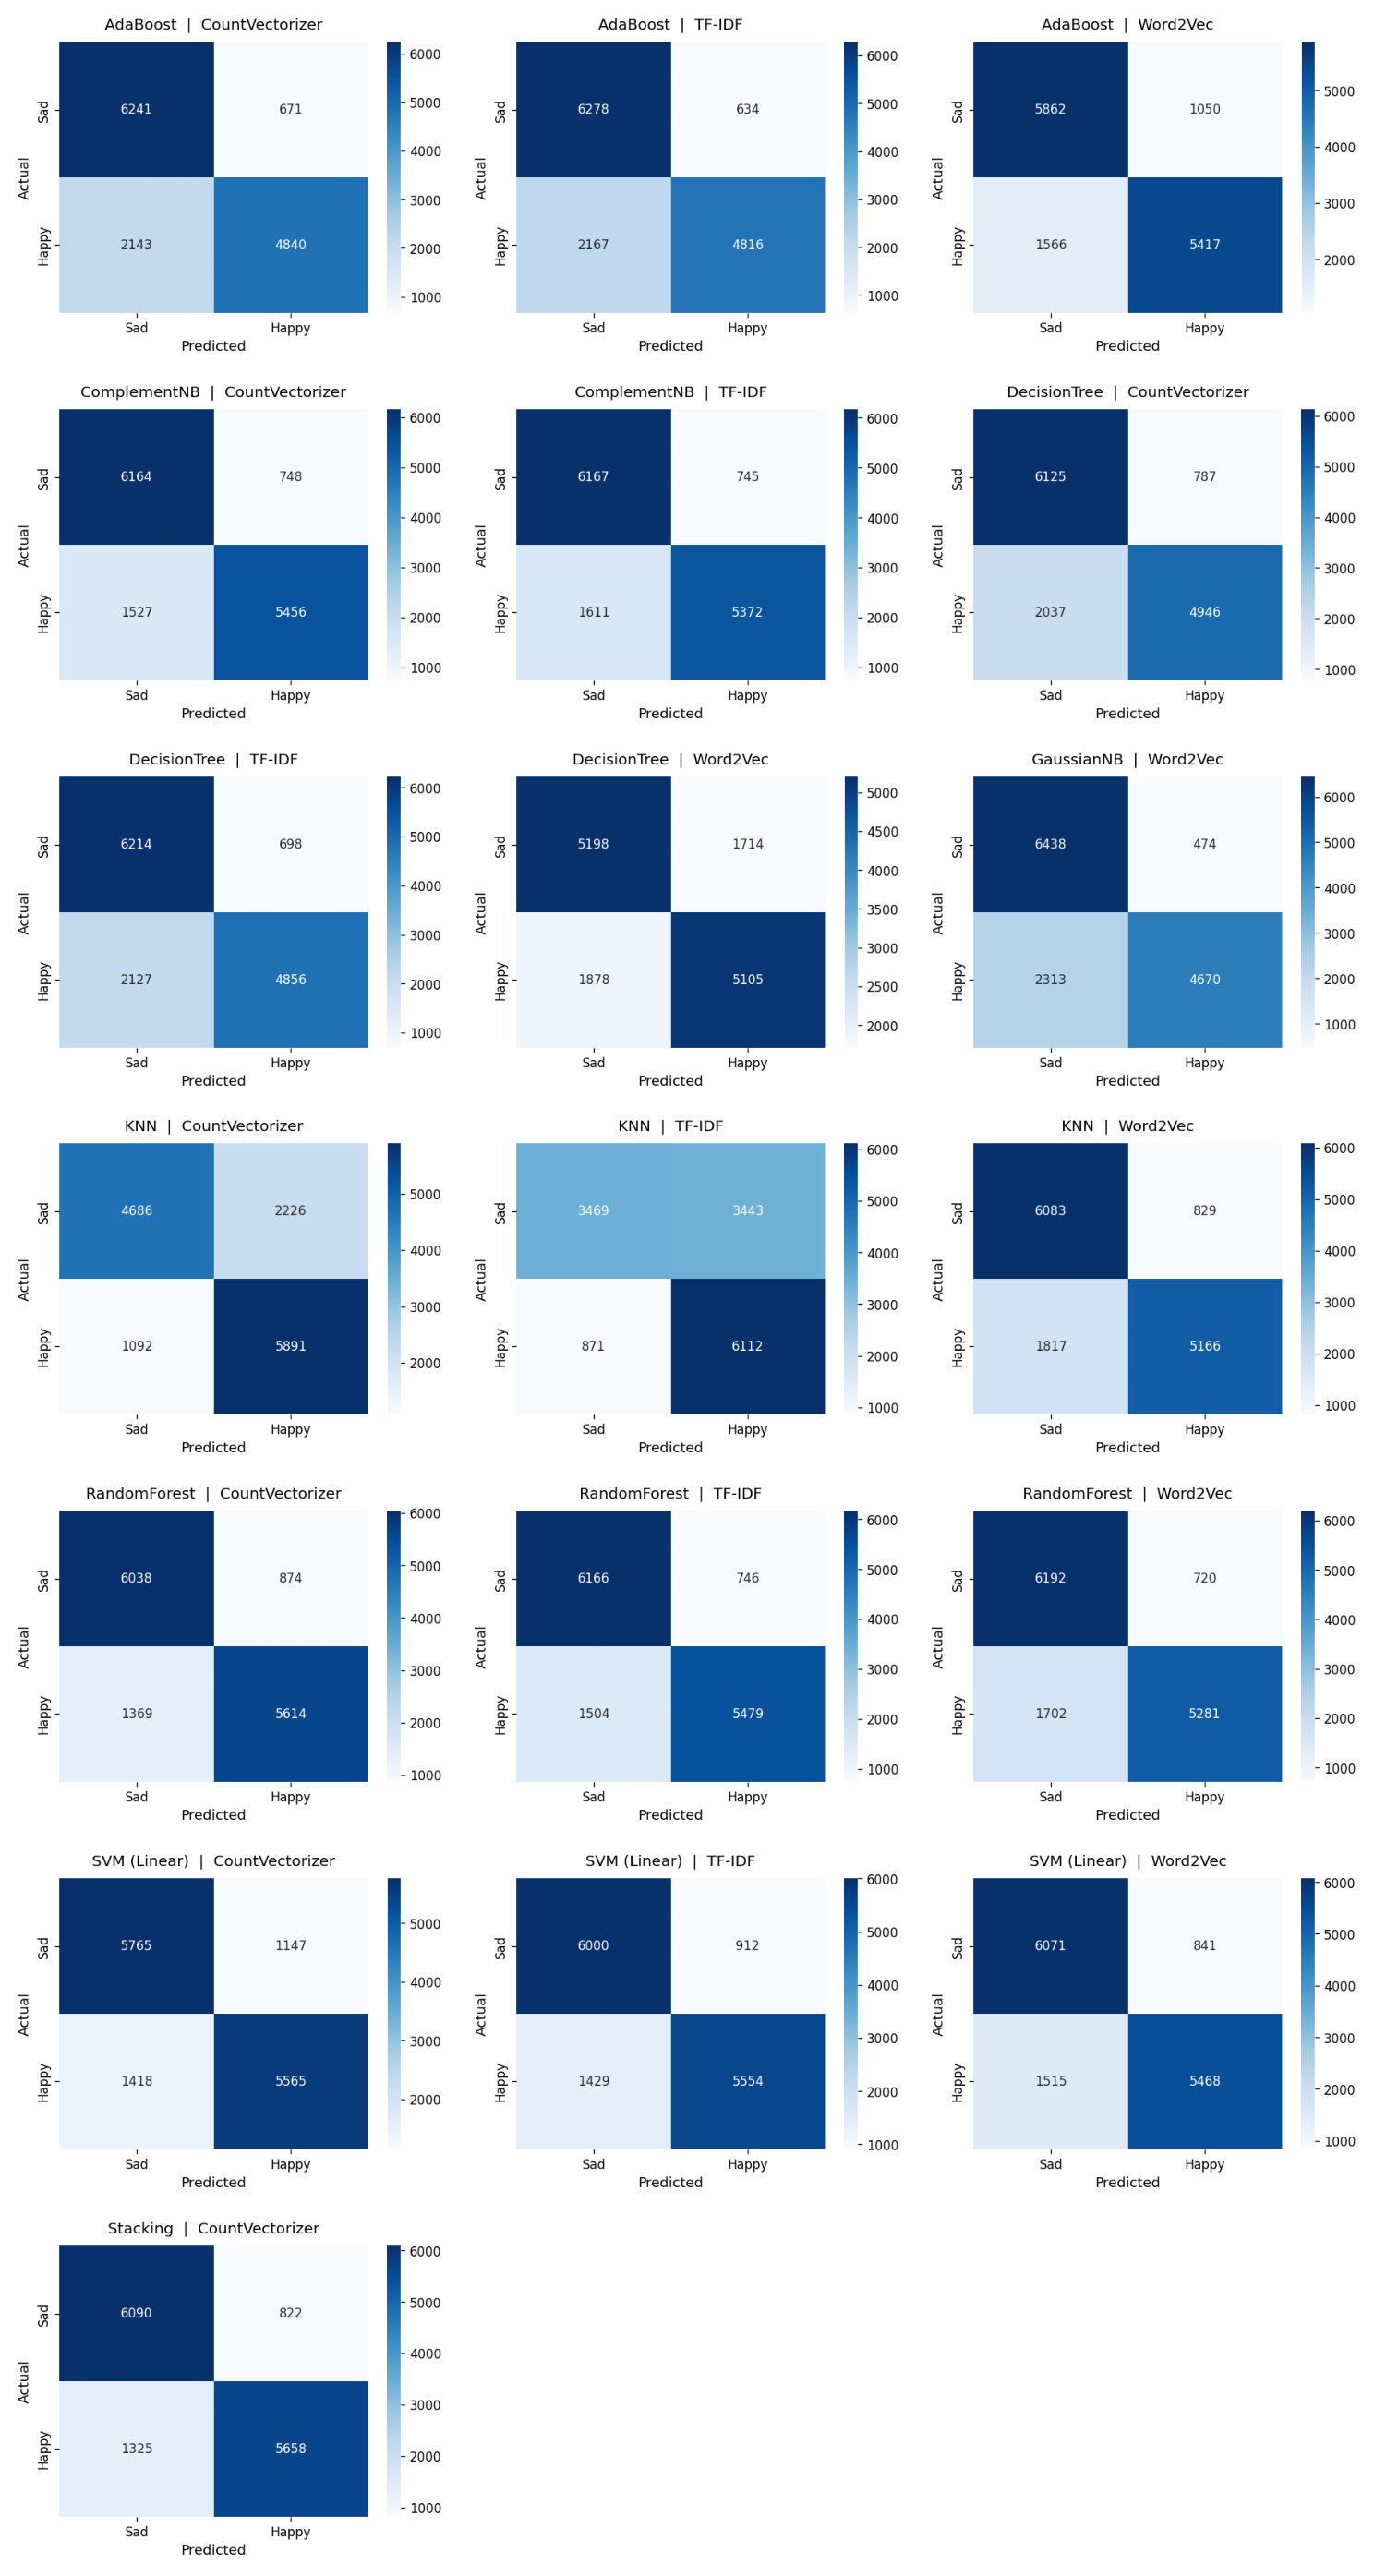

In [7]:
import glob
from matplotlib.image import imread

cm_files = sorted(glob.glob(os.path.join(CM_DIR, '*.png')))
n = len(cm_files)
cols = 3
rows = (n + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(5 * cols, 4 * rows))
axes = axes.flatten()

for i, fpath in enumerate(cm_files):
    img = imread(fpath)
    axes[i].imshow(img)
    axes[i].axis('off')

for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'all_confusion_matrices.png'), dpi=100, bbox_inches='tight')
plt.show()

## 5. Performance Comparison Bar Chart

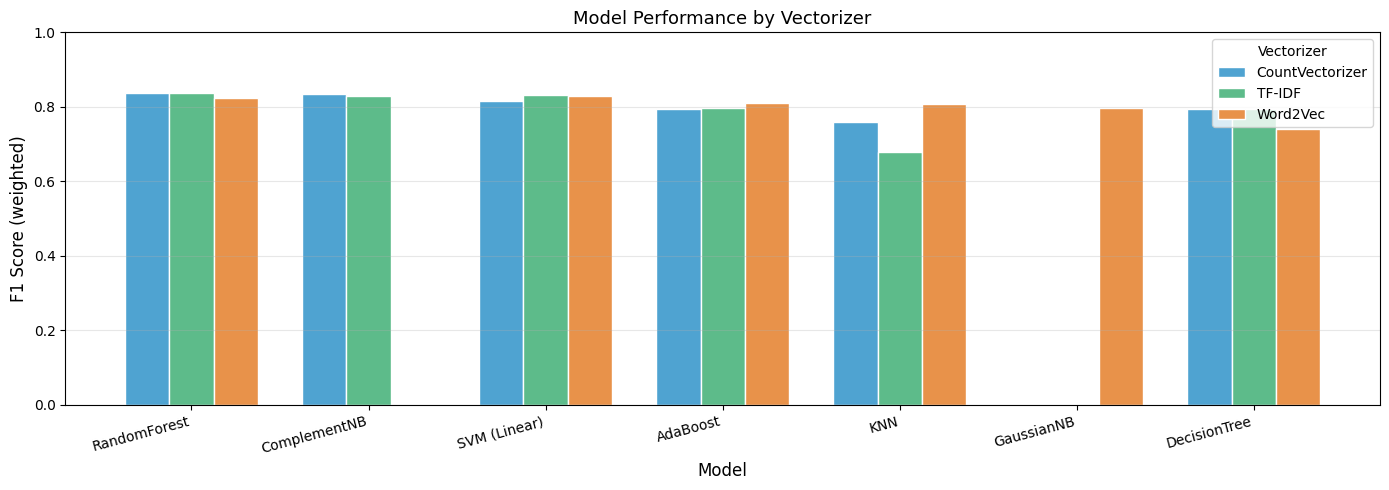

In [8]:
colors = {'CountVectorizer': '#4FA3D1', 'TF-IDF': '#5DBB8A', 'Word2Vec': '#E8924A'}
vec_names = results_df['vectorizer'].unique()
model_names_ordered = results_df.groupby('model')['f1'].max().sort_values(ascending=False).index

x = np.arange(len(model_names_ordered))
width = 0.25

fig, ax = plt.subplots(figsize=(14, 5))

for i, vec in enumerate(vec_names):
    vec_data = results_df[results_df['vectorizer'] == vec].set_index('model')
    f1_vals = [vec_data.loc[m, 'f1'] if m in vec_data.index else 0 for m in model_names_ordered]
    offset = (i - 1) * width
    bars = ax.bar(x + offset, f1_vals, width, label=vec, color=colors[vec], edgecolor='white')

ax.set_xlabel('Model', fontsize=12)
ax.set_ylabel('F1 Score (weighted)', fontsize=12)
ax.set_title('Model Performance by Vectorizer', fontsize=13)
ax.set_xticks(x)
ax.set_xticklabels(model_names_ordered, rotation=15, ha='right')
ax.set_ylim(0, 1.0)
ax.legend(title='Vectorizer')
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'phase3_f1_comparison.png'), dpi=120, bbox_inches='tight')
plt.show()

## 6. Best Model Analysis

In [9]:
best_row = results_df.loc[results_df['f1'].idxmax()]
print(f'Best model      : {best_row["model"]}')
print(f'Best vectorizer : {best_row["vectorizer"]}')
print(f'Accuracy        : {best_row["accuracy"]:.4f}')
print(f'Precision       : {best_row["precision"]:.4f}')
print(f'Recall          : {best_row["recall"]:.4f}')
print(f'F1              : {best_row["f1"]:.4f}')

Best model      : RandomForest
Best vectorizer : CountVectorizer
Accuracy        : 0.8386
Precision       : 0.8404
Recall          : 0.8386
F1              : 0.8384


## 7. Correct & Incorrect Prediction Examples (Best Model)

In [10]:
# Re-run best model to get predictions for example display
best_model_name = best_row['model']
best_vec_name   = best_row['vectorizer']

vec_map = {'CountVectorizer': (X_train_count, X_test_count),
           'TF-IDF':          (X_train_tfidf, X_test_tfidf),
           'Word2Vec':        (X_train_w2v,   X_test_w2v)}

model_map = {m[0]: m[1] for m in models}
best_model = model_map[best_model_name]

X_tr_b, X_te_b = vec_map[best_vec_name]
if sp.issparse(X_tr_b) and isinstance(best_model, GaussianNB):
    X_tr_b = X_tr_b.toarray()
    X_te_b = X_te_b.toarray()

best_model.fit(X_tr_b, y_train)
y_pred_best = best_model.predict(X_te_b)

full_report(best_model_name, best_vec_name, y_test, y_pred_best)

print(f'\n--- Prediction Examples: {best_model_name} + {best_vec_name} ---')
show_prediction_examples(
    texts=X_test_texts,
    y_true=y_test,
    y_pred=y_pred_best,
    n=5,
    label_map={0: 'Sad', 1: 'Happy'}
)


Model: RandomForest   |   Vectorizer: CountVectorizer
              precision    recall  f1-score   support

         Sad       0.82      0.87      0.84      6912
       Happy       0.87      0.80      0.83      6983

    accuracy                           0.84     13895
   macro avg       0.84      0.84      0.84     13895
weighted avg       0.84      0.84      0.84     13895


--- Prediction Examples: RandomForest + CountVectorizer ---
CORRECT PREDICTIONS (showing 5)
  Text  : کیک یخ‌زده محتویات لای کیک جمله گردو موز سفت
  True  : Sad   |   Predicted: Sad
----------------------------------------------------------------------
  Text  : شیرینی نارگیل قسمت کیکیش بیات توی جعبه شیرینی ناپلئون بد رولت واقعا کهنه لطیفه خامه معمولی
  True  : Sad   |   Predicted: Sad
----------------------------------------------------------------------
  Text  : شیرینی رولت صورت لهشذه خورد دستم
  True  : Sad   |   Predicted: Sad
----------------------------------------------------------------------
  Text  

## 8. Summary

**Next:** Phase 4 — Vectorizer Selection (`04_vectorizer_selection.ipynb`)